In [1]:
import pandas as pd

### load the dataset

In [ ]:
df1 = pd.read_csv("../Dataset/train_feature.csv")
df2 = pd.read_csv("../Dataset/val_feature.csv")

In [4]:
df = pd.concat([df1, df2], ignore_index=True)

In [5]:
df.head()

,acc_x_mean,acc_x_std,acc_x_min,acc_x_max,acc_y_mean,acc_y_std,acc_y_min,acc_y_max,acc_z_mean,acc_z_std,...,resp_min,resp_max,net_acc_mean,net_acc_std,net_acc_min,net_acc_max,ecg_peak_freq,resp_peak_freq,temp_slope,eda_slope
0,0.913389,0.005173,0.8776,0.9638,-0.016038,0.010455,-0.0658,0.0358,0.043496,0.028134,...,-16.688538,16.481018,0.915060,0.004632,0.883394,0.989889,4.066667,0.200000,-8.423019e-07,1.554092e-06
1,0.775276,0.022214,0.6970,0.9678,-0.184002,0.052689,-0.3142,-0.0678,-0.507589,0.042673,...,-8.822632,7.829285,0.947340,0.013927,0.794010,1.059903,3.966667,0.166667,-2.676707e-06,-7.402926e-08
2,0.844760,0.010883,0.7996,0.9000,-0.047909,0.008220,-0.0802,0.0148,-0.383692,0.030006,...,-18.453979,15.028381,0.929622,0.004910,0.876027,0.987237,4.500000,0.166667,-9.494872e-08,3.896091e-07
3,0.811792,0.020951,0.7038,0.8766,0.140401,0.019233,0.1080,0.2504,-0.406958,0.036177,...,-7.411194,8.108521,0.919995,0.007705,0.845042,0.983438,8.666667,0.266667,4.149441e-06,-1.361384e-06
4,0.386626,0.007746,0.3634,0.4148,0.024698,0.003729,0.0122,0.0382,-0.884721,0.005916,...,-7.810974,8.177185,0.965874,0.004242,0.950112,0.985387,7.200000,0.133333,2.022522e-06,-4.088488e-07


### Load the model

In [6]:
import pickle
model = pickle.load(open("../ModelTraining/model.pkl", "rb"))

In [7]:
row = 1

input = df.iloc[row].values.reshape(1, -1)
model.predict(input)

array([0])

### Lime

In [8]:
from lime.lime_tabular import LimeTabularExplainer
explainer = LimeTabularExplainer(
    training_data=df.values,
    feature_names=df.columns,
    mode="classification",
    discretize_continuous=False
)

In [9]:
explanation = explainer.explain_instance(
    data_row=df.iloc[0].values,   
    predict_fn=model.predict_proba,
    num_features=100
)

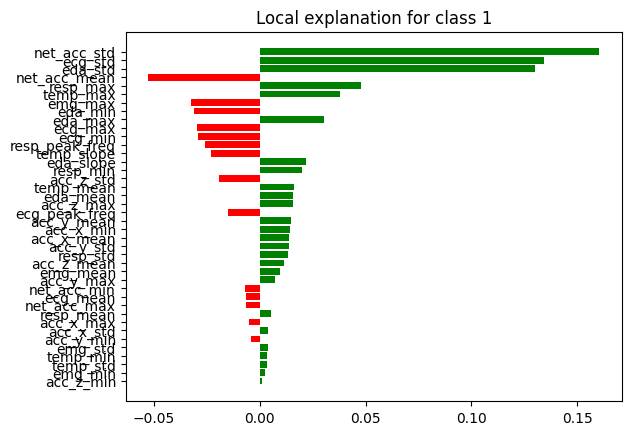

In [10]:
import matplotlib.pyplot as plt

fig = explanation.as_pyplot_figure()
plt.show()

In [15]:
exp = explanation.as_list()

explanation = explainer.explain_instance(
    data_row=df.iloc[0].values,
    predict_fn=model.predict_proba,
    num_features=10   # ← THIS controls top-k
)

explanation.save_to_file("lime_top10.html")